In [ ]:
import json

with open('results_qwen_3_5_9B_ce_new.json', 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)

qwen_9B_entropies = []
qwen_9B_y_true = []
for i in loaded_results.keys():
  #print(loaded_results[i])
  if loaded_results[i]['logits_history'] != None:
    for step in loaded_results[i]['logits_history']:
        #print(step)
        if step['has_correct'] == False:
            #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                qwen_9B_y_true.append(1)
                qwen_9B_entropies.append(step['entropy'])
        elif step['has_correct'] == True:
      #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                qwen_9B_y_true.append(0)
                qwen_9B_entropies.append(step['entropy'])
#y_true

In [ ]:
import json

with open('/content/results_gemma_4B_ce_new.json', 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)

gemma_4B_entropies = []
gemma_4B_y_true = []
for i in loaded_results.keys():
  #print(loaded_results[i])
  if loaded_results[i]['logits_history'] != None:
    for step in loaded_results[i]['logits_history']:
        #print(step)
        if step['has_correct'] == False:
            #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                gemma_4B_y_true.append(1)
                gemma_4B_entropies.append(step['entropy'])
        elif step['has_correct'] == True:
      #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                gemma_4B_y_true.append(0)
                gemma_4B_entropies.append(step['entropy'])
#y_true

In [ ]:
import json

with open('/content/results_llama_8B_Instruct_ce_new.json', 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)

llama_8B_entropies = []
llama_8B_y_true = []
for i in loaded_results.keys():
  #print(loaded_results[i])
  if loaded_results[i]['logits_history'] != None:
    for step in loaded_results[i]['logits_history']:
        #print(step)
        if step['has_correct'] == False:
            #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                llama_8B_y_true.append(1)
                llama_8B_entropies.append(step['entropy'])
        elif step['has_correct'] == True:
      #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                llama_8B_y_true.append(0)
                llama_8B_entropies.append(step['entropy'])
#y_true

In [ ]:
import json

with open('/content/results_qwen_3_5_4B_ce_new.json', 'r', encoding='utf-8') as f:
    loaded_results = json.load(f)

qwen_4B_entropies = []
qwen_4B_y_true = []
for i in loaded_results.keys():
  #print(loaded_results[i])
  if loaded_results[i]['logits_history'] != None:
    for step in loaded_results[i]['logits_history']:
        #print(step)
        if step['has_correct'] == False:
            #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                qwen_4B_y_true.append(1)
                qwen_4B_entropies.append(step['entropy'])
        elif step['has_correct'] == True:
      #entropies.append(step['entropy'])
            if step['action'][:5] == 'INDEX':
                qwen_4B_y_true.append(0)
                qwen_4B_entropies.append(step['entropy'])
#y_true

Qwen 3.5 4B
0.13333333333333333 0.51183970856102
Gemma 4B
0.17073170731707318 0.36939313984168864
Qwen 3.5 9B
0.20574162679425836 0.5701598579040853
Llama 8B Instruct
0.6307692307692307 0.8266978922716628


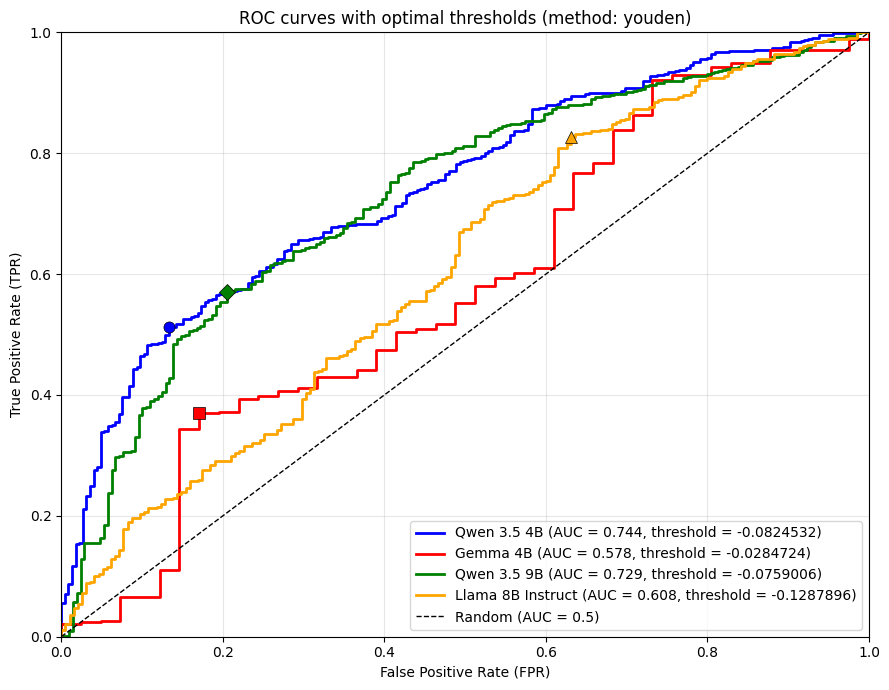

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
import numpy as np

# Пример данных (замените на свои массивы)
# y_true1, scores1 и т.д. – ваши исходные данные
# y_true1 = np.array([0, 1, 0, 1, ...])
# scores1 = np.array([0.1, 0.9, 0.2, 0.8, ...])

# Объединяем данные в списки для удобства
y_trues = [qwen_4B_y_true, gemma_4B_y_true, qwen_9B_y_true, llama_8B_y_true]
scores_list = [[-e for e in qwen_4B_entropies], [-e for e in gemma_4B_entropies],[-e for e in qwen_9B_entropies], [-e for e in llama_8B_entropies]]
labels = ['Qwen 3.5 4B', 'Gemma 4B', 'Qwen 3.5 9B', 'Llama 8B Instruct']  # подписи кривых

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# ========== ВАШИ ДАННЫЕ ==========
# y_true1, scores1, y_true2, scores2, y_true3, scores3, y_true4, scores4
# =================================

def find_optimal_threshold(y_true, y_scores, method='youden'):
    """
    Возвращает оптимальный порог и координаты (fpr, tpr) для него.
    method: 'youden' (максимум Youden's J = TPR - FPR)
            'closest' (ближайшая точка к (0,1) по евклидову расстоянию)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    if method == 'youden':
        youden = tpr - fpr
        best_idx = np.argmax(youden)
    elif method == 'closest':
        dist = np.sqrt((1 - tpr)**2 + fpr**2)
        best_idx = np.argmin(dist)
    else:
        raise ValueError("method должен быть 'youden' или 'closest'")

    best_threshold = thresholds[best_idx]
    best_point = (fpr[best_idx], tpr[best_idx])
    return best_threshold, best_point, fpr, tpr

# Параметры
method = 'youden'  # или 'closest'
colors = ['blue', 'red', 'green', 'orange']
markers = ['o', 's', 'D', '^']

plt.figure(figsize=(9, 7))

for i, (y_true, y_scores) in enumerate(zip(y_trues, scores_list)):
    # Получаем оптимальный порог и все ROC-данные
    best_thr, best_pt, fpr, tpr = find_optimal_threshold(y_true, y_scores, method)
    roc_auc = auc(fpr, tpr)
    print(labels[i])
    print(best_pt[0], best_pt[1])
    csv_df = pd.DataFrame(
        {
            'FPR': fpr,
            'TPR':tpr
        }
    )
    opt_csv_df = pd.DataFrame(
        {
            'FPR': [best_pt[0]],
            'TPR':[best_pt[1]]
        }
    )
    csv_df.to_csv(f"{'_'.join(labels[i].split())}.csv",index = False)
    opt_csv_df.to_csv(f"{'_'.join(labels[i].split())}_opt.csv",index = False)

    # Строим ROC-кривую
    plt.plot(fpr, tpr, lw=2, color=colors[i],
             label=f'{labels[i]} (AUC = {roc_auc:.3f}, threshold = {best_thr:.7f})')

    # Отмечаем оптимальную точку
    plt.plot(best_pt[0], best_pt[1], marker=markers[i], markersize=8,
             color=colors[i], markeredgecolor='black', markeredgewidth=0.5)

# Диагональ (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')

# Оформление
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC curves with optimal thresholds (method: {method})')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ROC_curves.png')
plt.show()

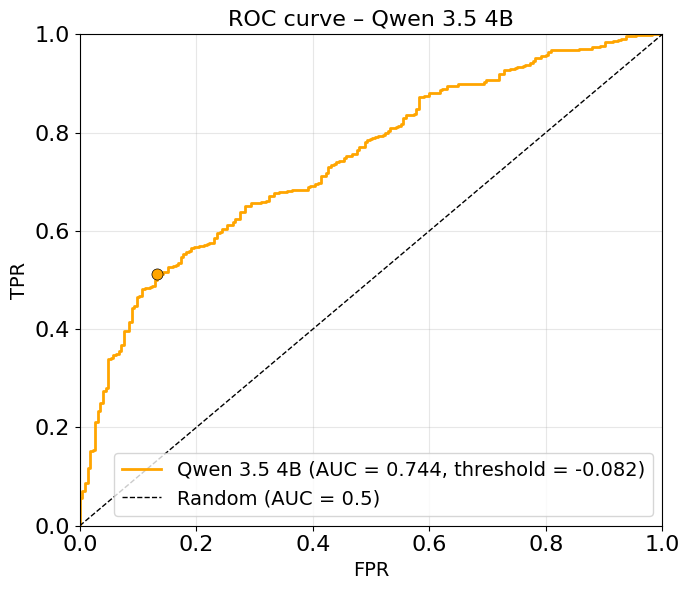

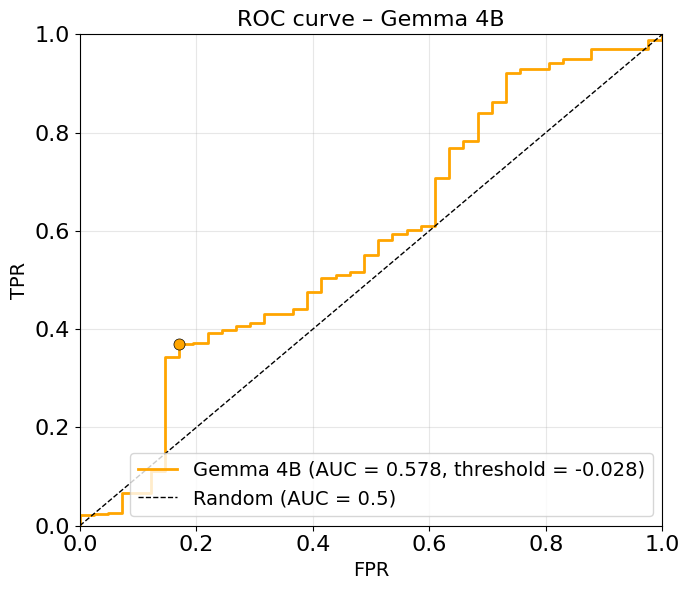

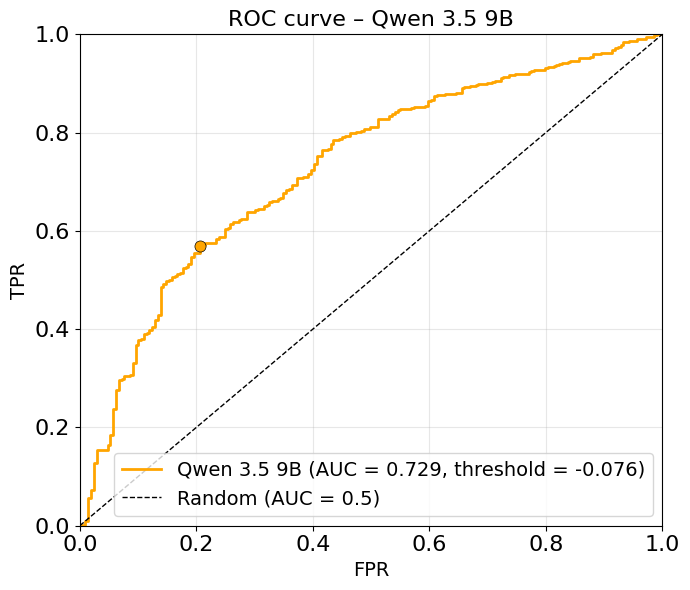

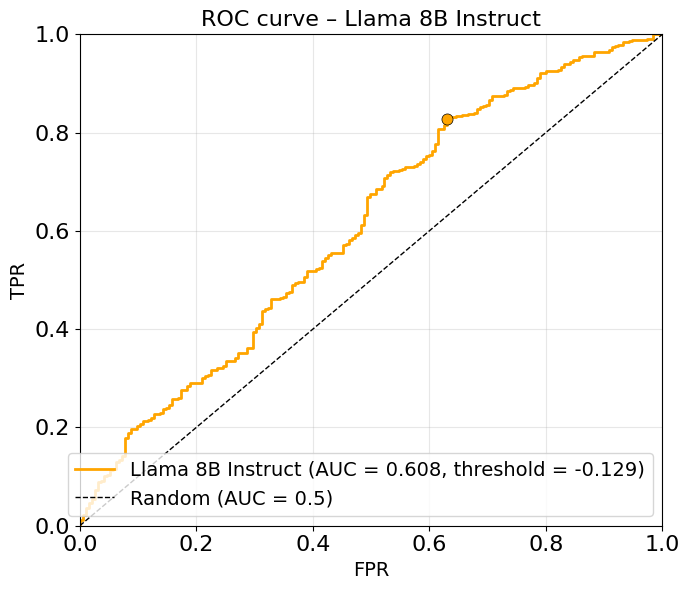

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# ========== ПРЕДПОЛАГАЕМЫЕ ДАННЫЕ (замените на свои) ==========
y_trues = [qwen_4B_y_true, gemma_4B_y_true, qwen_9B_y_true, llama_8B_y_true]
scores_list = [[-e for e in qwen_4B_entropies], [-e for e in gemma_4B_entropies],
               [-e for e in qwen_9B_entropies], [-e for e in llama_8B_entropies]]
labels = ['Qwen 3.5 4B', 'Gemma 4B', 'Qwen 3.5 9B', 'Llama 8B Instruct']


def find_optimal_threshold(y_true, y_scores, method='youden'):
    """
    Возвращает оптимальный порог и координаты (fpr, tpr) для него.
    method: 'youden' (максимум Youden's J = TPR - FPR)
            'closest' (ближайшая точка к (0,1) по евклидову расстоянию)
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    if method == 'youden':
        youden = tpr - fpr
        best_idx = np.argmax(youden)
    elif method == 'closest':
        dist = np.sqrt((1 - tpr)**2 + fpr**2)
        best_idx = np.argmin(dist)
    else:
        raise ValueError("method должен быть 'youden' или 'closest'")

    best_threshold = thresholds[best_idx]
    best_point = (fpr[best_idx], tpr[best_idx])
    return best_threshold, best_point, fpr, tpr

# Параметры
method = 'youden'                 # или 'closest'
single_color = 'orange'             # один цвет для всех графиков
marker = 'o'                      # маркер для оптимальной точки

# Размеры шрифтов (по заданию)
fontsize_label = 14       # подписи осей (xlabel, ylabel)
fontsize_tick = 16        # цифры на осях
fontsize_title = 16       # заголовок графика
fontsize_legend = 14      # легенда

# Цикл по всем моделям – строим отдельный график для каждой
for i, (y_true, y_scores) in enumerate(zip(y_trues, scores_list)):
    # Получаем оптимальный порог и все ROC-данные
    best_thr, best_pt, fpr, tpr = find_optimal_threshold(y_true, y_scores, method)
    roc_auc = auc(fpr, tpr)

    # Создаём новую фигуру
    plt.figure(figsize=(7, 6))

    # Строим ROC-кривую одним цветом
    plt.plot(fpr, tpr, lw=2, color=single_color,
             label=f'{labels[i]} (AUC = {roc_auc:.3f}, threshold = {best_thr:.3f})')

    # Отмечаем оптимальную точку
    plt.plot(best_pt[0], best_pt[1], marker=marker, markersize=8,
             color=single_color, markeredgecolor='black', markeredgewidth=0.5)

    # Диагональ (случайный классификатор)
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')

    # Настройка внешнего вида
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('FPR', fontsize=fontsize_label)
    plt.ylabel('TPR', fontsize=fontsize_label)
    plt.title(f'ROC curve – {labels[i]}', fontsize=fontsize_title)

    # Настройка размера шрифта делений осей
    plt.tick_params(axis='both', labelsize=fontsize_tick)

    # Легенда
    plt.legend(loc='lower right', fontsize=fontsize_legend)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Сохраняем график в отдельный файл
    filename = f'ROC_curve_{labels[i].replace(" ", "_")}.png'
    plt.savefig(filename)
    plt.show()   # (опционально, можно убрать)

In [ ]:
plt.savefig('ROC_curves.png')

<Figure size 640x480 with 0 Axes>